In [12]:
import os
import cv2
import numpy as np
# for creating a responsive plot
# %matplotlib widget
# importing required libraries
# from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import torch
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import frontalize
import subprocess
import importlib  
crop_video = importlib.import_module("crop-video")
%matplotlib inline
import glob
import webinterface
from tqdm import tqdm

In [2]:
palsy_images = glob.glob("E:/Datasets/Facial Palsy Datasets/MEEI Standard Set/*/*/*/*.jpg") + glob.glob("E:/Datasets/Facial Palsy Datasets/MEEI Standard Set/*/*/*.jpg")
for image_path in tqdm(palsy_images):
    try:
        identity = image_path.split("\\")[-1][:-4]
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        webinterface.mirror_face_image(image, identity, "palsy_mirrored_faces")
    except:
        pass
    
    

100%|████████████████████████████████████████████████████████████████████████████████| 480/480 [11:32<00:00,  1.44s/it]


In [2]:
import feat

In [2]:
from PIL import Image, ImageOps
import math, cv2, csv
from scipy.spatial import ConvexHull
from skimage.morphology.convex_hull import grid_points_in_poly
from feat import Detector
import os, glob, pandas as pd, numpy as np
from skimage.feature import hog
from tqdm import tqdm


def padding(img, expected_size):
    desired_size = expected_size
    delta_width = desired_size - img.size[0]
    delta_height = desired_size - img.size[1]
    pad_width = delta_width // 2
    pad_height = delta_height // 2
    padding = (
        pad_width,
        pad_height,
        delta_width - pad_width,
        delta_height - pad_height,
    )
    return ImageOps.expand(img, padding)


def resize_with_padding(img, expected_size):
    img.thumbnail((expected_size[0], expected_size[1]))
    delta_width = expected_size[0] - img.size[0]
    delta_height = expected_size[1] - img.size[1]
    pad_width = delta_width // 2
    pad_height = delta_height // 2
    padding = (
        pad_width,
        pad_height,
        delta_width - pad_width,
        delta_height - pad_height,
    )
    return ImageOps.expand(img, padding)


def align_face_68pts(img, img_land, box_enlarge, img_size=112):
    """
    img: image
    img_land: landmarks 68
    box_enlarge: relative size of face
    img_size = 112

    """
    leftEye0 = (
        img_land[2 * 36]
        + img_land[2 * 37]
        + img_land[2 * 38]
        + img_land[2 * 39]
        + img_land[2 * 40]
        + img_land[2 * 41]
    ) / 6.0
    leftEye1 = (
        img_land[2 * 36 + 1]
        + img_land[2 * 37 + 1]
        + img_land[2 * 38 + 1]
        + img_land[2 * 39 + 1]
        + img_land[2 * 40 + 1]
        + img_land[2 * 41 + 1]
    ) / 6.0
    rightEye0 = (
        img_land[2 * 42]
        + img_land[2 * 43]
        + img_land[2 * 44]
        + img_land[2 * 45]
        + img_land[2 * 46]
        + img_land[2 * 47]
    ) / 6.0
    rightEye1 = (
        img_land[2 * 42 + 1]
        + img_land[2 * 43 + 1]
        + img_land[2 * 44 + 1]
        + img_land[2 * 45 + 1]
        + img_land[2 * 46 + 1]
        + img_land[2 * 47 + 1]
    ) / 6.0
    deltaX = rightEye0 - leftEye0
    deltaY = rightEye1 - leftEye1
    l = math.sqrt(deltaX * deltaX + deltaY * deltaY)
    sinVal = deltaY / l
    cosVal = deltaX / l
    mat1 = np.mat([[cosVal, sinVal, 0], [-sinVal, cosVal, 0], [0, 0, 1]])
    mat2 = np.mat(
        [
            [leftEye0, leftEye1, 1],
            [rightEye0, rightEye1, 1],
            [img_land[2 * 30], img_land[2 * 30 + 1], 1],
            [img_land[2 * 48], img_land[2 * 48 + 1], 1],
            [img_land[2 * 54], img_land[2 * 54 + 1], 1],
        ]
    )
    mat2 = (mat1 * mat2.T).T
    cx = float((max(mat2[:, 0]) + min(mat2[:, 0]))) * 0.5
    cy = float((max(mat2[:, 1]) + min(mat2[:, 1]))) * 0.5
    if float(max(mat2[:, 0]) - min(mat2[:, 0])) > float(
        max(mat2[:, 1]) - min(mat2[:, 1])
    ):
        halfSize = 0.5 * box_enlarge * float((max(mat2[:, 0]) - min(mat2[:, 0])))
    else:
        halfSize = 0.5 * box_enlarge * float((max(mat2[:, 1]) - min(mat2[:, 1])))
    scale = (img_size - 1) / 2.0 / halfSize
    mat3 = np.mat(
        [
            [scale, 0, scale * (halfSize - cx)],
            [0, scale, scale * (halfSize - cy)],
            [0, 0, 1],
        ]
    )
    mat = mat3 * mat1
    aligned_img = cv2.warpAffine(
        img,
        mat[0:2, :],
        (img_size, img_size),
        cv2.INTER_LINEAR,
        borderValue=(128, 128, 128),
    )
    land_3d = np.ones((int(len(img_land) / 2), 3))
    land_3d[:, 0:2] = np.reshape(np.array(img_land), (int(len(img_land) / 2), 2))
    mat_land_3d = np.mat(land_3d)
    new_land = np.array((mat * mat_land_3d.T).T)
    new_land = np.array(list(zip(new_land[:, 0], new_land[:, 1]))).astype(int)
    return aligned_img, new_land


def extract_hog(image, detector):
    im = cv2.imread(image)
    detected_faces = np.array(detector.detect_faces(im)[0])
    if np.any(detected_faces < 0):
        orig_size = np.array(im).shape
        if np.where(detected_faces < 0)[0][0] == 1:
            new_size = (
                orig_size[0],
                int(orig_size[1] + 2 * abs(detected_faces[detected_faces < 0][0])),
            )
        else:
            new_size = (
                int(orig_size[0] + 2 * abs(detected_faces[detected_faces < 0][0])),
                orig_size[1],
            )
        im = resize_with_padding(Image.fromarray(im), new_size)
        im = np.asarray(im)
        detected_faces = np.array(detector.detect_faces(np.array(im))[0])
    detected_faces = detected_faces.astype(int)
    points = np.array(detector.detect_landmarks(np.array(im), [detected_faces.tolist()])[0]).astype(int)

    aligned_img, points = align_face_68pts(im, points.flatten(), 2.5)

    hull = ConvexHull(points)
    mask = grid_points_in_poly(
        shape=np.array(aligned_img).shape,
        verts=list(
            zip(points[hull.vertices][:, 1], points[hull.vertices][:, 0])
        ),  # for some reason verts need to be flipped
    )

    mask[0 : np.min([points[0][1], points[16][1]]), points[0][0] : points[16][0]] = True
    aligned_img[~mask] = 0
    resized_face_np = aligned_img

    fd, hog_image = hog(
        resized_face_np,
        orientations=8,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        visualize=True,
        multichannel=True,
    )

    return fd, hog_image, points

In [3]:

EmotioNet_images = np.sort(glob.glob(os.path.join("E:/Datasets/EmotioNet/images", "*.jpg")))

In [9]:
dataset = "EmotionNet"
labels_filename = "emotionet_labels.csv"
landmarks_filename = "emotionet_landmarks.csv"

detector = Detector(face_model="retinaface", landmark_model="mobilenet")
EmotioNet_images = np.sort(glob.glob(os.path.join("E:/Datasets/EmotioNet/images", "*.jpg")))
labels = pd.read_csv(
    os.path.join("E:/Datasets/EmotioNet/EmotioNet_FACS_aws_2020_24600.csv")
)
labels = labels.dropna(axis=0)
for col in labels.columns:
    if "AU" in col:
        kwargs = {col.replace("'", "").replace('"', "").replace(" ", ""): labels[[col]]}
        labels = labels.assign(**kwargs)
        labels = labels.drop(columns=col)
labels = labels.assign(
    URL=labels.URL.apply(lambda x: x.split("/")[-1].replace("'", ""))
)
labels = labels.set_index("URL")
labels = labels.drop(columns=["URL orig"])

aus_to_train = [
    "AU1",
    "AU2",
    "AU4",
    "AU5",
    "AU6",
    "AU7",
    "AU9",
    "AU10",
    "AU11",
    "AU12",
    "AU14",
    "AU15",
    "AU17",
    "AU20",
    "AU23",
    "AU24",
    "AU25",
    "AU26",
    "AU28",
    "AU43",
]

# with open(labels_filename, "w", newline="") as csvfile:
#     writer = csv.writer(csvfile, delimiter=",")
#     writer.writerow(["URL"] + aus_to_train)

# landmark_cols = [f"x_{i}" for i in range(68)] + [f"y_{i}" for i in range(68)]
# with open(landmarks_filename, "w", newline="") as csvfile:
#     writer = csv.writer(csvfile, delimiter=",")
#     writer.writerow(landmark_cols)

# for ix, image in enumerate(tqdm(EmotioNet_images)):
#     try:
#         imageURL = os.path.split(image)[-1]
#         label = labels.loc[imageURL][aus_to_train]
#         fd, _, points = extract_hog(image, detector=detector)
#         with open(labels_filename, "a+", newline="") as csvfile:
#             writer = csv.writer(csvfile, delimiter=",")
#             writer.writerow([imageURL] + list(label.values))
#         with open(landmarks_filename, "a+", newline="") as csvfile:
#             writer = csv.writer(csvfile, delimiter=",")
#             writer.writerow(points.T.flatten())
#     except:
#         print(f"failed {image}")

In [7]:
mirrored_faces = glob.glob("mirrored_faces/*.png")

for image in mirrored_faces:
    
    fd, _, points = extract_hog(image, detector=detector)

In [4]:
def extract_hog_withface(image, detector):
    im = cv2.imread(image)
    detected_faces = np.array(detector.detect_faces(im)[0])
    if np.any(detected_faces < 0):
        orig_size = np.array(im).shape
        if np.where(detected_faces < 0)[0][0] == 1:
            new_size = (
                orig_size[0],
                int(orig_size[1] + 2 * abs(detected_faces[detected_faces < 0][0])),
            )
        else:
            new_size = (
                int(orig_size[0] + 2 * abs(detected_faces[detected_faces < 0][0])),
                orig_size[1],
            )
        im = resize_with_padding(Image.fromarray(im), new_size)
        im = np.asarray(im)
        detected_faces = np.array(detector.detect_faces(np.array(im))[0])
    detected_faces = detected_faces.astype(int)
    points = np.array(detector.detect_landmarks(np.array(im), [detected_faces.tolist()])[0]).astype(int)

    aligned_img, points = align_face_68pts(im, points.flatten(), 2.5)

    hull = ConvexHull(points)
    mask = grid_points_in_poly(
        shape=np.array(aligned_img).shape,
        verts=list(
            zip(points[hull.vertices][:, 1], points[hull.vertices][:, 0])
        ),  # for some reason verts need to be flipped
    )

    mask[0 : np.min([points[0][1], points[16][1]]), points[0][0] : points[16][0]] = True
    aligned_img[~mask] = 0
    resized_face_np = aligned_img

    fd, hog_image = hog(
        resized_face_np,
        orientations=8,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        visualize=True,
        multichannel=True,
    )

    return fd, hog_image, points, resized_face_np

In [5]:
def local_weighted_regression(x0, X, Y, tau):
    x0 = np.r_[1, x0]
    X = np.c_[np.ones(len(X)), X]
     
    xw = X.T * weights_calculate(x0, X, tau)
    theta = np.linalg.pinv(xw @ X) @ xw @ Y

    return x0 @ theta
 
def weights_calculate(x0, X, tau):
    return np.exp(np.sum((X - x0) ** 2, axis=1) / (-2 * (tau **2) ))
def mask_side_cut(image, cut_line, padding=0):
    cut_line_tiled = np.tile(cut_line[:,None], (1,image.shape[1]))
    mask_right = np.zeros((image.shape[0], image.shape[1]))
    xx, yy = np.meshgrid(np.arange(image.shape[0]), np.arange(image.shape[1]))
    mask_right[xx <= cut_line_tiled + padding] = 1
    

    mask_left = np.zeros((image.shape[0], image.shape[1]))
    mask_left[xx >= cut_line_tiled - padding] = 1
    
    return mask_right.astype(int), mask_left.astype(int)

In [6]:
def extract_hog_half_face(image, detector):
    im = cv2.imread(image)
    detected_faces = np.array(detector.detect_faces(im)[0])
    if np.any(detected_faces < 0):
        orig_size = np.array(im).shape
        if np.where(detected_faces < 0)[0][0] == 1:
            new_size = (
                orig_size[0],
                int(orig_size[1] + 2 * abs(detected_faces[detected_faces < 0][0])),
            )
        else:
            new_size = (
                int(orig_size[0] + 2 * abs(detected_faces[detected_faces < 0][0])),
                orig_size[1],
            )
        im = resize_with_padding(Image.fromarray(im), new_size)
        im = np.asarray(im)
        detected_faces = np.array(detector.detect_faces(np.array(im))[0])
    detected_faces = detected_faces.astype(int)
    points = np.array(detector.detect_landmarks(np.array(im), [detected_faces.tolist()])[0]).astype(int)

    aligned_img, points = align_face_68pts(im, points.flatten(), 2.5)

    hull = ConvexHull(points)
    mask = grid_points_in_poly(
        shape=np.array(aligned_img).shape,
        verts=list(
            zip(points[hull.vertices][:, 1], points[hull.vertices][:, 0])
        ),  # for some reason verts need to be flipped
    )

    mask[0 : np.min([points[0][1], points[16][1]]), points[0][0] : points[16][0]] = True
    aligned_img[~mask] = 0
    resized_face_np = aligned_img
    
    landmarks=[27,28,29,30,33,51,62,66,57,8]
    cut_line = np.array([local_weighted_regression(y, points[landmarks,1], points[landmarks,0], tau=10) for y in range(resized_face_np.shape[1])])
    
    mask_right, mask_left = mask_side_cut(resized_face_np, cut_line, padding=5)
    
    fd_right, hog_image_right = hog(
        resized_face_np * mask_right[:,:,None],
        orientations=8,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        visualize=True,
        multichannel=True,
    )
    
    fd_left, hog_image_left = hog(
        resized_face_np * mask_left[:,:,None],
        orientations=8,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        visualize=True,
        multichannel=True,
    )

    return fd_right, hog_image_right, fd_left, hog_image_left, points, resized_face_np

In [7]:

landmarks=[27,28,29,30,33,51,62,66,57,8]

In [19]:
for ix, image in enumerate(tqdm(EmotioNet_images)):
    fd, hog_image, points, resized_face_np = extract_hog_withface(image, detector)
    break

  0%|                                                                                        | 0/24598 [00:01<?, ?it/s]


In [10]:
for ix, image in enumerate(tqdm(EmotioNet_images)):
#     image = 'E:/Datasets/EmotioNet/images\\N_0000000020_00600.jpg'
    fd_right, hog_image_right, fd_left, hog_image_left, points, resized_face_np = extract_hog_half_face(image, detector)
    resized_face_np = resized_face_np[:,:,::-1]
    break

  0%|                                                                                        | 0/24598 [00:01<?, ?it/s]


(-0.5, 111.5, 111.5, -0.5)

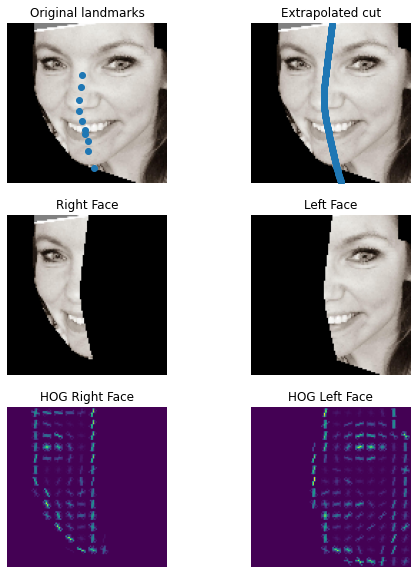

In [13]:
plt.figure(figsize=(8,10))
plt.subplot(321)
plt.imshow(resized_face_np)
plt.axis("off")
plt.scatter(points[landmarks,0],points[landmarks,1])
plt.title("Original landmarks")


plt.subplot(322)
plt.title("Extrapolated cut")
plt.imshow(resized_face_np)
plt.axis("off")
x = np.array([local_weighted_regression(y, points[landmarks,1], points[landmarks,0], tau=10) for y in range(112)])
plt.scatter(x, np.arange(112))

mask_right, mask_left = mask_side_cut(resized_face_np, x, padding=0)

plt.subplot(323)
plt.title("Right Face")
plt.imshow(resized_face_np * mask_right[:,:,None])
plt.axis("off")

plt.subplot(324)
plt.title("Left Face")
plt.imshow(resized_face_np * mask_left[:,:,None])
plt.axis("off")

plt.subplot(325)
plt.title("HOG Right Face")
plt.imshow(hog_image_right)
plt.axis("off")
plt.subplot(326)
plt.title("HOG Left Face")
plt.imshow(hog_image_left)
plt.axis("off")

In [24]:
# plt.imshow(hog_image)
# plt.axis("off")
# os.makedirs("hog_example", exist_ok=True)
im_name = image.replace("\\","/").split("/")[-1][:-4]
# plt.savefig("hog_example/{}-hog_image.png".format(im_name), dpi=300, bbox_inches="tight", pad_inches=0)
# plt.close()

plt.imshow(hog_image_right)
plt.axis("off")
plt.savefig("hog_example/{}-hog_image_right.png".format(im_name), dpi=300, bbox_inches="tight", pad_inches=0)
plt.close()

plt.imshow(hog_image_left)
plt.axis("off")
plt.savefig("hog_example/{}-hog_image_left.png".format(im_name), dpi=300, bbox_inches="tight", pad_inches=0)
plt.close()


plt.imshow(resized_face_np)
plt.axis("off")
plt.scatter(points[landmarks,0],points[landmarks,1])
plt.savefig("hog_example/{}-original_image_landmarks.png".format(im_name), dpi=300, bbox_inches="tight", pad_inches=0)
plt.close()


plt.imshow(resized_face_np)
plt.axis("off")
x = np.array([local_weighted_regression(y, points[landmarks,1], points[landmarks,0], tau=10) for y in range(112)])
plt.scatter(x, np.arange(112))
plt.savefig("hog_example/{}-original_image_extrap.png".format(im_name), dpi=300, bbox_inches="tight", pad_inches=0)
plt.close()



mask_right, mask_left = mask_side_cut(resized_face_np, x, padding=0)

plt.imshow(resized_face_np * mask_right[:,:,None])
plt.axis("off")
plt.savefig("hog_example/{}-mask_right.png".format(im_name), dpi=300, bbox_inches="tight", pad_inches=0)
plt.close()


plt.imshow(resized_face_np * mask_left[:,:,None])
plt.axis("off")
plt.savefig("hog_example/{}-mask_left.png".format(im_name), dpi=300, bbox_inches="tight", pad_inches=0)
plt.close()

In [27]:
image.replace("\\","/").split("/")[-1][:-4]

'N_0000000001_00001'

array([[  0,   1,   2, ..., 109, 110, 111],
       [  0,   1,   2, ..., 109, 110, 111],
       [  0,   1,   2, ..., 109, 110, 111],
       ...,
       [  0,   1,   2, ..., 109, 110, 111],
       [  0,   1,   2, ..., 109, 110, 111],
       [  0,   1,   2, ..., 109, 110, 111]])

In [78]:
np.tile(x[:,None], (1,112))

array([[56.48311597, 56.48311597, 56.48311597, ..., 56.48311597,
        56.48311597, 56.48311597],
       [56.35689423, 56.35689423, 56.35689423, ..., 56.35689423,
        56.35689423, 56.35689423],
       [56.23058854, 56.23058854, 56.23058854, ..., 56.23058854,
        56.23058854, 56.23058854],
       ...,
       [62.21500064, 62.21500064, 62.21500064, ..., 62.21500064,
        62.21500064, 62.21500064],
       [62.5291943 , 62.5291943 , 62.5291943 , ..., 62.5291943 ,
        62.5291943 , 62.5291943 ],
       [62.84684887, 62.84684887, 62.84684887, ..., 62.84684887,
        62.84684887, 62.84684887]])

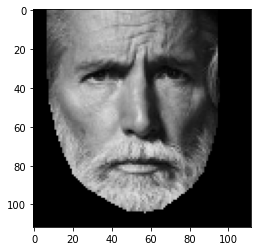

In [14]:
plt.imshow(resized_face_np)

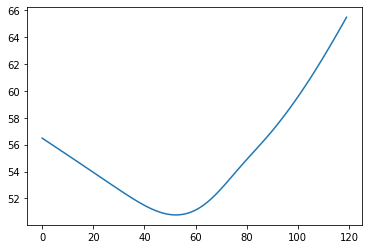

In [42]:
plt.plot([local_weighted_regression(x, points[landmarks,1], points[landmarks,0], tau=10) for x in range(120)])